# 综合题 · 成都二手房单价预测（第 3 章全章 · 里程碑 1 · 一轮交付件）

> 题型：**I 迁移**——把 ch03 学到的「数据 → 特征 → 模型 → 训练 → 评估」完整流程迁移到真实房价数据。
> 这是**里程碑 1** 和**一轮交付件**：做完后本文件可直接提交（提交时建议另存为 `chengdu_house_regression.ipynb`）。
>
> 难度：🚀 挑战（真实数据完整流水线）
> 做题流程：按第一步 → 第七步顺序补全 TODO（共 8 处），每步都有自测 cell，跑出 ✓ 再继续；做完再看 `solutions/综合题-答案.md`。

## 第一步 · 下载与检查数据集（对应一轮 Step 1）

1. 从阿里天池下载成都二手房数据：https://tianchi.aliyun.com/dataset/154888 （需登录）
2. 把下载的 csv 放到 `practice/data/` 下，**命名为 `chengdu_house.csv`**（与 FashionMNIST 同一目录）
3. 用 Excel 或 VS Code 打开 csv 扫一眼字段和样本情况

运行下面 cell 加载数据。如果列名与预期不同，改 `COL` 字典里的映射即可（不要改代码其他部分）。

In [73]:
%matplotlib inline
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils import data
import re
import os

# 列名映射：如果下载的数据集列名不同，改这里
COL = {
    '户型': '房屋户型',
    '楼层': '所在楼层',
    '面积': '建筑面积（平方米）',
    '市辖区': '房屋所属市辖区',
    '朝向': '房屋朝向',
    '装修': '装修情况',
    '结构': '建筑结构',
    '电梯': '配备电梯',
    '单价': '单价（元/平方米）',
}

CSV_PATH = '../data/chengdu_house.csv'
df = None
if not os.path.exists(CSV_PATH):
    print('⚠ 数据文件不存在！下载指引：')
    print('  https://tianchi.aliyun.com/dataset/154888')
    print('  下载后把 csv 放到 practice/data/ 下，命名为 chengdu_house.csv，再运行本 cell')
else:
    df = pd.read_csv(CSV_PATH)
    print('已加载，样本数:', len(df), ' 列数:', df.shape[1])
    print('列名:', df.columns.tolist())

已加载，样本数: 14838  列数: 16
列名: ['序号', '房屋所属市辖区', '房屋地址（街道）', '房屋户型', '所在楼层', '建筑面积（平方米）', '户型结构', '建筑类型', '房屋朝向', '建筑结构', '装修情况', '配备电梯', '挂牌时间', '交易权属', '房屋用途', '单价（元/平方米）']


### 观察数据（一轮 Step 1 的关注点）

先回答再运行下一 cell：

- 样本数量级大约多少？
- 哪些是数值字段、哪些是文本字段？
- 单位是否统一（面积用平方米、单价用元/平方米）？
- 缺失值、异常值大概有多少？

**【你的观察】**

In [49]:
if df is not None:
    print(df.info())
    print('\n数值字段统计:')
    print(df.describe())
    print('\n每列缺失值数量:')
    print(df.isnull().sum())
else:
    print('⚠ 数据未加载：先完成第一步')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   序号         14838 non-null  int64  
 1   房屋所属市辖区    14838 non-null  object 
 2   房屋地址（街道）   14838 non-null  object 
 3   房屋户型       14838 non-null  object 
 4   所在楼层       14838 non-null  object 
 5   建筑面积（平方米）  14838 non-null  float64
 6   户型结构       14838 non-null  object 
 7   建筑类型       14838 non-null  object 
 8   房屋朝向       14838 non-null  object 
 9   建筑结构       14838 non-null  object 
 10  装修情况       14838 non-null  object 
 11  配备电梯       14838 non-null  object 
 12  挂牌时间       14838 non-null  object 
 13  交易权属       14838 non-null  object 
 14  房屋用途       14838 non-null  object 
 15  单价（元/平方米）  14838 non-null  int64  
dtypes: float64(1), int64(2), object(13)
memory usage: 1.8+ MB
None

数值字段统计:
                 序号     建筑面积（平方米）      单价（元/平方米）
count  14838.000000  14838.000000   14838.000

## 第二步 · 特征工程（对应一轮 Step 2）

特征方案（先想清楚每一步「为什么」，写在预测区）：

- **数值**：建筑面积、户型拆出的室/厅/厨/卫、楼层位置（低/中/高编码 0/1/2）、总楼层
- **类别 one-hot**：市辖区、朝向、装修、建筑结构、电梯
- **缺失值**：数值填中位数、类别填「未知」
- **异常值**：面积 ≤0 或 >500、单价 ≤0 的行删除
- **标准化**：数值列用训练集的均值/标准差做 z-score

**【你的预测】**（为什么类别要 one-hot 而不是编数字？为什么需要标准化？）

In [3]:
help(re.search)

Help on function search in module re:

search(pattern, string, flags=0)
    Scan through string looking for a match to the pattern, returning
    a Match object, or None if no match was found.



In [74]:
def parse_hu_xing(s):
    # TODO 综合题 1: 用正则从「2室1厅1厨1卫」提取 (室, 厅, 厨, 卫)。
    # 某一项缺失时填 0（如「3室2厅2卫」→ 厨=0）
    # 提示: re.search(r'(\d+)室', str(s))，取不到就填 0
    def get_num(pattern):
        m = re.search(pattern, str(s))   # 匹配
        return int(m.group(1)) if m else 0   # 匹配到取数字，否则填 0

    return (get_num(r'(\d+)室'), get_num(r'(\d+)厅'), get_num(r'(\d+)厨'), get_num(r'(\d+)卫'))

In [75]:
try:
    assert parse_hu_xing('2室1厅1厨1卫') == (2, 1, 1, 1)
    assert parse_hu_xing('3室2厅2卫') == (3, 2, 0, 2)
    assert parse_hu_xing('1室0厅1厨1卫') == (1, 0, 1, 1)
    print('✓ 户型解析正确')
except NotImplementedError as e:
    print(f'⚠ {e}')
except AssertionError as e:
    print(f'✗ {e}')

✓ 户型解析正确


In [76]:
def parse_floor(s):
    # TODO 综合题 2: 从「高楼层 (共7层)」提取 (位置编码, 总楼层)。
    # 位置编码: 低=0、中=1、高=2；总楼层取不到时返回 None
    def get_floor_type():
        if '高' in s:
            num = 2
        elif '中' in s:
            num = 1
        elif '低' in s:
            num = 0
        else:
            return 1
        return num
        
    def get_floor_num(pattern):
        n = re.search(pattern, str(s))
        return int(n.group(1)) if n else None
        
    return((get_floor_type(), get_floor_num(r'共(\d+)层')))

In [77]:
try:
    assert parse_floor('高楼层 (共7层)') == (2, 7)
    assert parse_floor('低楼层 (共31层)') == (0, 31)
    assert parse_floor('中楼层') == (1, None)
    print('✓ 楼层解析正确')
except NotImplementedError as e:
    print(f'⚠ {e}')
except AssertionError as e:
    print(f'✗ {e}')

✓ 楼层解析正确


In [78]:
def build_features(df):
    """原始 DataFrame -> 特征 DataFrame（数值 + one-hot）"""
    feat = pd.DataFrame()
    hu = df[COL['户型']].apply(parse_hu_xing)
    feat['室'] = [h[0] for h in hu]
    feat['厅'] = [h[1] for h in hu]
    feat['厨'] = [h[2] for h in hu]
    feat['卫'] = [h[3] for h in hu]
    fl = df[COL['楼层']].apply(parse_floor)
    feat['楼层位置'] = [f[0] for f in fl]
    feat['总楼层'] = [f[1] for f in fl]
    feat['建筑面积'] = df[COL['面积']]
    # TODO 综合题 3: 对下面每个类别列做 one-hot（get_dummies）并拼接到 feat。
    # 提示: 先 fillna('未知') 再 one-hot，避免出现整行全 0
    cat_cols = [COL['市辖区'], COL['朝向'], COL['装修'], COL['结构'], COL['电梯']]
    for col in cat_cols:
        filled = df[col].fillna('未知')
        dummies = pd.get_dummies(filled, prefix=col)
        feat = pd.concat([feat, dummies], axis=1)

    return feat

In [79]:
try:
    feat_df = build_features(df)
    print('✓ 特征表形状:', feat_df.shape)
    print('特征列（前 15 个）:', feat_df.columns.tolist()[:15])
except NotImplementedError as e:
    print(f'⚠ {e}')
except TypeError as e:
    print(f'⚠ 数据未加载或前面的 TODO 未完成: {e}')

✓ 特征表形状: (14838, 128)
特征列（前 15 个）: ['室', '厅', '厨', '卫', '楼层位置', '总楼层', '建筑面积', '房屋所属市辖区_双流', '房屋所属市辖区_天府新区', '房屋所属市辖区_崇州', '房屋所属市辖区_彭州', '房屋所属市辖区_成华', '房屋所属市辖区_新津', '房屋所属市辖区_新都', '房屋所属市辖区_武侯']


### 缺失值与异常值（TODO 综合题 4）

缺失值处理：总楼层/面积等数值列填**中位数**。
异常值处理：面积 ≤0 或 >500、单价 ≤0 的整行删除。

In [80]:
def clean_data(feat_df, label_series):
    # TODO 综合题 4: 先拷贝一份；数值列缺失值用中位数填充；
    # 然后构造掩码过滤异常行（面积<=0 或 >500、单价<=0），返回 (清理后特征, 清理后标签)
    # 提示: 真实数据里数值列可能混有「暂无」这类字符串，
    #       用 pd.to_numeric(列, errors='coerce') 先把非数字转成 NaN 再填充
    feat = feat_df.copy()
    label = label_series.copy()
    feat['总楼层'] = pd.to_numeric(feat['总楼层'], errors='coerce')
    feat['建筑面积'] = pd.to_numeric(feat['建筑面积'], errors='coerce')
    feat['总楼层'] = feat['总楼层'].fillna(feat['总楼层'].median())
    feat['建筑面积'] = feat['建筑面积'].fillna(feat['建筑面积'].median())
    mask = (feat['建筑面积'] > 0) & (feat['建筑面积'] <= 500) & (label > 0)
    
    return feat[mask].reset_index(drop=True), label[mask].reset_index(drop=True)

In [81]:
try:
    X_raw, y_raw = clean_data(build_features(df), df[COL['单价']])
    print('✓ 清理前样本数:', len(df), ' 清理后样本数:', len(X_raw))
    print('✓ 清理后特征形状:', X_raw.shape)
except NotImplementedError as e:
    print(f'⚠ {e}')
except TypeError as e:
    print(f'⚠ 数据未加载或前面的 TODO 未完成: {e}')

✓ 清理前样本数: 14838  清理后样本数: 14834
✓ 清理后特征形状: (14834, 128)


## 第三步 · 划分、标准化、张量转换（对应一轮 Step 3）

- 随机划分 80% 训练 / 20% 测试
- 数值列用**训练集**的均值/标准差做标准化（测试集也用它，不能用自己的——为什么？）
- 标签同样标准化（记住 train 的均值/标准差，预测新样本时要反变换回真实价格）
- 转成 torch.FloatTensor，用 DataLoader 分批

**【你的预测】**

In [82]:
NUM_COLS = ['室', '厅', '厨', '卫', '楼层位置', '总楼层', '建筑面积']

try:
    X_raw, y_raw = clean_data(build_features(df), df[COL['单价']])
    # TODO 综合题 5: 用 torch.randperm 随机划分 80/20；
    # 计算「训练集」数值列的均值/标准差与标签的均值/标准差；
    # 对训练/测试特征做标准化（写成函数复用），标签做同样标准化

    num_examples = len(X_raw)
    idx = torch.randperm(num_examples).tolist()
    n_train = int(0.8 * num_examples)
    train_idx, test_idx = idx[:n_train], idx[n_train:]

    train_mean = X_raw.iloc[train_idx][NUM_COLS].mean()
    train_std = X_raw.iloc[train_idx][NUM_COLS].std()
    y_mean = float(y_raw.iloc[train_idx].mean())
    y_std = float(y_raw.iloc[train_idx].std())

    def norm(part):
        out = part.copy()
        out[NUM_COLS] = (out[NUM_COLS] - train_mean) / train_std
        return out

    X_train = norm(X_raw.iloc[train_idx]).reset_index(drop = True)
    X_test = norm(X_raw.iloc[test_idx]).reset_index(drop=True)
    y_train = (y_raw.iloc[train_idx].values - y_mean) / y_std
    y_test = (y_raw.iloc[test_idx].values - y_mean) / y_std

    print('X_train 形状:', X_train.shape, ' X_test 形状:', X_test.shape)
except NotImplementedError as e:
    print(f'⚠ {e}（TODO 3/4/5 完成后再运行）')
except TypeError as e:
    print(f'⚠ 数据未加载或前面的 TODO 未完成: {e}')

X_train 形状: (11867, 128)  X_test 形状: (2967, 128)


In [83]:
try:
    # TODO 综合题 6: X_train/X_test 用 .values 转成 torch.FloatTensor，
    # y_train/y_test 转成列向量 FloatTensor；
    # 用 TensorDataset + DataLoader 建 train_iter（batch_size=64, shuffle=True）
    train_ds = data.TensorDataset(
        torch.tensor(X_train.astype('float32').values),
        torch.tensor(y_train.astype('float32')).reshape(-1, 1))
    train_iter = data.DataLoader(train_ds, batch_size = 64, shuffle = True)
    X_test_t = torch.tensor(X_test.astype('float32').values)
    y_test_t = torch.tensor(y_test.astype('float32')).reshape(-1, 1)
    print('✓ 训练批次数:', len(train_iter))
except NotImplementedError as e:
    print(f'⚠ {e}')
except TypeError as e:
    print(f'⚠ 数据未加载或前面的 TODO 未完成: {e}')

✓ 训练批次数: 186


## 第四步 · 模型与训练（对应一轮 Step 4/5）

模型 = `nn.Sequential(nn.Linear(特征数, 1))`；损失 = MSELoss；优化器 = Adam(lr=0.05)；epochs=50。
训练三步照抄 ex03 的模板：zero_grad → backward → step，每 epoch 记录平均损失。

先预测：因为标签做了标准化，训练损失大约会收敛到什么数量级？（提示：噪声 / 标签标准差）

In [109]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
try:
    # TODO 综合题 7: 创建模型/损失/优化器，补全训练循环（zero_grad→backward→step），
    # 每 epoch 记录平均损失到 history 列表，每 10 个 epoch 打印一次
    net = nn.Sequential(nn.Linear(128, 1)).to(device)
    trainer = torch.optim.SGD(net.parameters(), lr = 0.1)
    loss = nn.MSELoss()
    epochs = 200
    history = []
    for epoch in range(epochs):
        epoch_l = 0.0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            trainer.zero_grad()
            l.backward()
            trainer.step()
            epoch_l += float(l) * len(X)
        history.append(epoch_l / len(X_train))
        if (epoch + 1) % 10 == 0:
            print(f'epoch {epoch + 1}, loss {history[-1]:.4f}')
    print('✓ 训练完成')
except NotImplementedError as e:
    print(f'⚠ {e}')
except TypeError as e:
    print(f'⚠ 数据未加载或前面的 TODO 未完成: {e}')

epoch 10, loss 0.2757
epoch 20, loss 0.2742
epoch 30, loss 0.2749
epoch 40, loss 0.2746
epoch 50, loss 0.2741
epoch 60, loss 0.2741
epoch 70, loss 0.2741
epoch 80, loss 0.2745
epoch 90, loss 0.2737
epoch 100, loss 0.2754
epoch 110, loss 0.2720
epoch 120, loss 0.2714
epoch 130, loss 0.2782
epoch 140, loss 0.2701
epoch 150, loss 0.2718
epoch 160, loss 0.2738
epoch 170, loss 0.2713
epoch 180, loss 0.2714
epoch 190, loss 0.2744
epoch 200, loss 0.2739
✓ 训练完成


D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23610 (\N{CJK UNIFIED IDEOGRAPH-5C3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\an

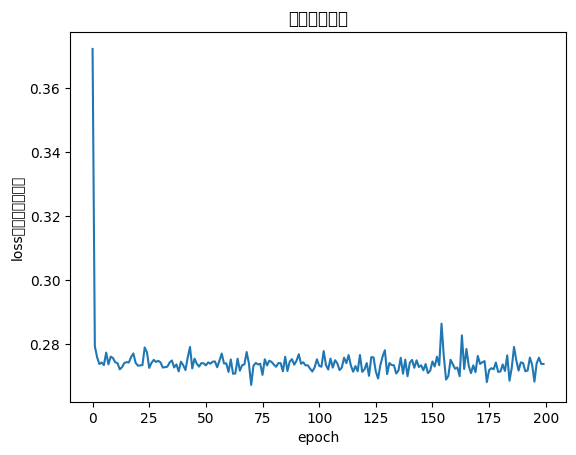

In [110]:
if 'history' in dir() and len(history) > 0:
    import matplotlib.pyplot as plt
    plt.plot(history)
    plt.xlabel('epoch')
    plt.ylabel('loss（标准化尺度）')
    plt.title('训练损失曲线')
    plt.show()

## 第六步 · 评估与新样本预测（对应一轮 Step 6）

- 在测试集上计算 **RMSE**（均方根误差）和 **MAE**（平均绝对误差），单位是**真实的元/平方米**（要先反变换）
- 对一轮要求的新样本做预测：

| 市辖区 | 户型 | 楼层 | 面积 | 朝向 | 结构 | 装修 | 电梯 |
|---|---|---|---|---|---|---|---|
| 青羊 | 2室1厅1厨1卫 | 高楼层 (共7层) | 87.22 | 北 | 砖混结构 | 精装 | 无 |

提示：新样本要**走一遍同样的特征工程**（build_features → 对齐列 → 标准化 → 模型 → 反变换）。

In [107]:
try:
    # TODO 综合题 8a: 用 net 预测测试集（torch.no_grad），标准化尺度算 RMSE/MAE 后
    # 再乘回 y_std 加 y_mean，得到真实元/平方米
    net.eval()
    with torch.no_grad():
        pred_test = net(X_test_t.to(device)).reshape(-1)
        pred_real = pred_test * y_std + y_mean
        y_real = y_test_t.to(device).reshape(-1) * y_std + y_mean
        rmse = float(((pred_real - y_real) ** 2).mean() ** 0.5)
        mae = float((pred_real - y_real).abs().mean())

    print(f'✓ 测试集 RMSE: {rmse:.0f} 元/平方米  MAE: {mae:.0f} 元/平方米')

    # TODO 综合题 8b: 对一轮要求的新样本走完整流程并预测
    new_sample = pd.DataFrame([{
    COL['市辖区']: '青羊', COL['户型']: '2室1厅1厨1卫',
    COL['楼层']: '高楼层 (共7层)', COL['面积']: 87.22,
    COL['朝向']: '北', COL['装修']: '精装', COL['结构']: '砖混结构',
    COL['电梯']: '无',
}])
    def predict_price(sample_df):
        feat = build_features(sample_df)
        feat = feat.reindex(columns=X_train.columns, fill_value=0)    #补列
        feat = norm(feat)
        x = torch.tensor(feat.astype('float32').values)
        with torch.no_grad():
            return net(x.to(device)).item() * y_std + y_mean

    new_pred = predict_price(new_sample)
  
    print(f'✓ 新样本（青羊 外金沙 87.22㎡ 精装）预测单价: {new_pred:.0f} 元/平方米')
except NotImplementedError as e:
    print(f'⚠ {e}')
except TypeError as e:
    print(f'⚠ 数据未加载或前面的 TODO 未完成: {e}')

✓ 测试集 RMSE: 5496 元/平方米  MAE: 3533 元/平方米
✓ 新样本（青羊 外金沙 87.22㎡ 精装）预测单价: 15996 元/平方米


## 第七步 · 拓展（选做，对应一轮 Step 7）

- 换特征组合（去掉/加入市辖区、朝向等）对比 RMSE
- 对单价取 log 再回归，看 RMSE 是否下降（房价常呈对数正态分布）
- 画出「面积 vs 单价」散点图，观察关系
- 面试可讲：特征工程的每一步为什么这样做（标准化、one-hot、异常过滤）

## 提交清单（对应一轮「提交形式」）

- [ ] 数据加载和预处理
- [ ] 特征工程（户型正则、类别 one-hot、标准化）
- [ ] 数据集划分（80/20）
- [ ] 线性回归模型（nn.Linear + Adam + MSELoss）
- [ ] 训练循环与损失曲线
- [ ] 测试集评估（RMSE，MAE）
- [ ] 对新样本的预测
- [ ] （选做）拓展实验

提交方式：另存为 `chengdu_house_regression.ipynb`，按一轮要求发送给出题人。